In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



#Read the CSV Files


In [ ]:
customers = pd.read_csv("Capstone Customers.csv")
orders = pd.read_csv("Capstone Orders.csv")

customers.head()
orders.head()


#Check Missing Values


In [ ]:
print(customers.isnull().sum())

print(orders.isnull().sum())


#Remove Duplicate Rows


In [ ]:
customers.drop_duplicates(inplace=True)

orders.drop_duplicates(inplace=True)

print(customers.duplicated().sum())

print(orders.duplicated().sum())


#Standardize Text


In [ ]:
customers["Region"] = customers["Region"].str.strip().str.title()

customers["CustomerName"] = customers["CustomerName"].str.strip().str.title()

orders["Category"] = orders["Category"].str.strip().str.title()

print(customers["Region"].unique())

print(orders["Category"].unique())


#Handle Missing Values Correctly


In [ ]:
orders["Sales"] = orders["Sales"].fillna(orders["Sales"].median())

orders["Profit"] = orders["Profit"].fillna(orders["Profit"].median())

orders["Quantity"] = orders["Quantity"].fillna(orders["Quantity"].median())

orders["Discount"] = orders["Discount"].fillna(orders["Discount"].median())

customers["Region"] = customers["Region"].fillna("Unknown")

orders["Category"] = orders["Category"].fillna("Unknown")

print(customers.isnull().sum())

print(orders.isnull().sum())


#Convert OrderDate


In [ ]:
orders["OrderDate"] = pd.to_datetime(
    orders["OrderDate"],
    dayfirst=True,
    errors="coerce"
)

print(orders.dtypes)



#Merge Both Tables


In [ ]:
df = pd.merge(
    customers,
    orders,
    on="CustomerID"
)

df.head()


#Validate Data


In [ ]:
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.head())


OUTPUT:
CustomerID      0
CustomerName    0
Region          0
Segment         0
JoinDate        0
dtype: int64
OrderID       0
CustomerID    0
OrderDate     0
Category      0
Sales         4
Quantity      0
Discount      0
Profit        4
dtype: int64
0
0
<StringArray>
['East', 'South', 'North', 'West', 'Central']
Length: 5, dtype: str
<StringArray>
['Electronics', 'Beauty', 'Clothing', 'Sports', 'Books', 'Home & Kitchen']
Length: 6, dtype: str
CustomerID      0
CustomerName    0
Region          0
Segment         0
JoinDate        0
dtype: int64
OrderID       0
CustomerID    0
OrderDate     0
Category      0
Sales         0
Quantity      0
Discount      0
Profit        0
dtype: int64
OrderID                int64
CustomerID             int64
OrderDate     datetime64[us]
Category                 str
Sales                float64
Quantity               int64
Discount             float64
Profit               float64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   CustomerID    500 non-null    int64         
 1   CustomerName  500 non-null    str           
 2   Region        500 non-null    str           
 3   Segment       500 non-null    str           
 4   JoinDate      500 non-null    str           
 5   OrderID       500 non-null    int64         
 6   OrderDate     500 non-null    datetime64[us]
 7   Category      500 non-null    str           
 8   Sales         500 non-null    float64       
 9   Quantity      500 non-null    int64         
 10  Discount      500 non-null    float64       
 11  Profit        500 non-null    float64       
dtypes: datetime64[us](1), float64(3), int64(3), str(5)
memory usage: 47.0 KB
None
       CustomerID      OrderID                   OrderDate        Sales   Quantity   Discount       Profit
count  500.000000   500.000000                         500   500.000000  500.00000  500.00000   500.000000
mean    33.466000  7250.500000  2024-07-07 07:23:31.200000   220.383100    3.85400    0.07540   201.251080
min      1.000000  7001.000000         2024-01-01 00:00:00     7.290000   -6.00000    0.00000 -2428.770000
25%     15.000000  7125.750000         2024-04-09 18:00:00    49.800000    2.00000    0.00000    33.302500
50%     32.000000  7250.500000         2024-07-12 12:00:00   103.925000    4.00000    0.05000    83.735000
75%     50.250000  7375.250000         2024-10-06 00:00:00   268.602500    6.00000    0.11250   228.242500
max     70.000000  7500.000000         2024-12-31 00:00:00  1196.170000    7.00000    0.30000  3046.000000
std     20.389908   144.481833                         NaN   277.929379    2.12455    0.07173   423.474963
CustomerID      0
CustomerName    0
Region          0
Segment         0
JoinDate        0
OrderID         0
OrderDate       0
Category        0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64
   CustomerID CustomerName Region    Segment    JoinDate  OrderID  OrderDate        Category   Sales  Quantity  Discount   Profit
0           1   Ananya Das   East  Corporate  19-08-2023     7017 2024-06-17     Electronics  636.93         7      0.05  1514.78
1           1   Ananya Das   East  Corporate  19-08-2023     7202 2024-08-27          Beauty   13.12         3      0.05    14.09
2           1   Ananya Das   East  Corporate  19-08-2023     7235 2024-11-11  Home & Kitchen  361.86         4      0.15   502.68
3           1   Ananya Das   East  Corporate  19-08-2023     7286 2024-10-10     Electronics  189.97         4      0.10   280.26
4           1   Ananya Das   East  Corporate  19-08-2023     7320 2024-09-10     Electronics  104.56         6      0.10   103.89
   OrderDate Month
0 2024-06-17   Jun
1 2024-08-27   Aug
2 2024-11-11   Nov
3 2024-10-10   Oct
4 2024-09-10   Sep

#Create a Month Column


In [ ]:
df["Month"] = df["OrderDate"].dt.strftime("%b")
print(df[["OrderDate","Month"]].head())


#1 A trend over time Monthly sales trend


In [ ]:
monthly_sales = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(12,6))

monthly_sales.plot(
    marker='o',
    color='blue',
    label='Sales'
)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.savefig("line_chart.png")

plt.show()

print("Insight: Highest monthly sales =", monthly_sales.max())


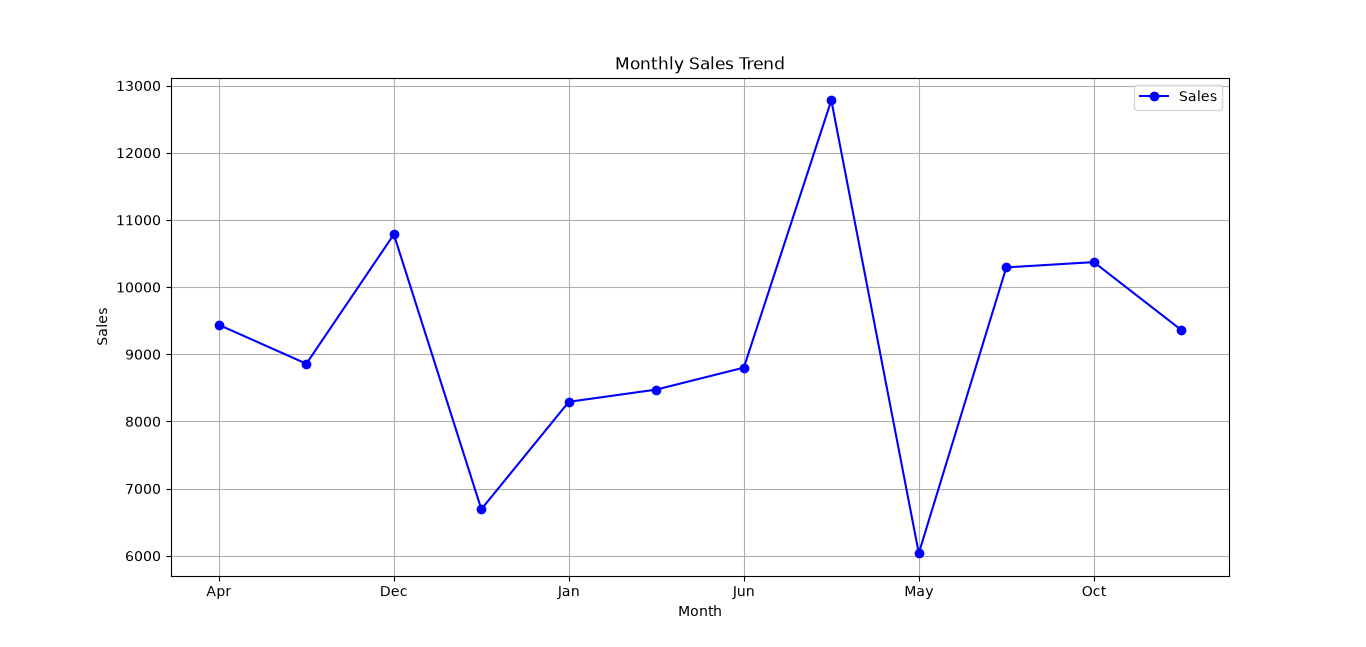

Insight: Highest monthly sales = 12781.525

#2 Bar chart — a metric compared across categorie


In [ ]:
category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8,6))

category_sales.plot(
    kind="bar",
    color="green",
    label="Sales"
)

plt.title("Sales by Category")

plt.xlabel("Category")

plt.ylabel("Sales")

plt.legend()

plt.savefig("Sales by Category.png")

plt.show()

print("Insight: Highest sales category =", category_sales.idxmax())


![sales by categoryo1.png](<attachment:sales by categoryo1.png>)
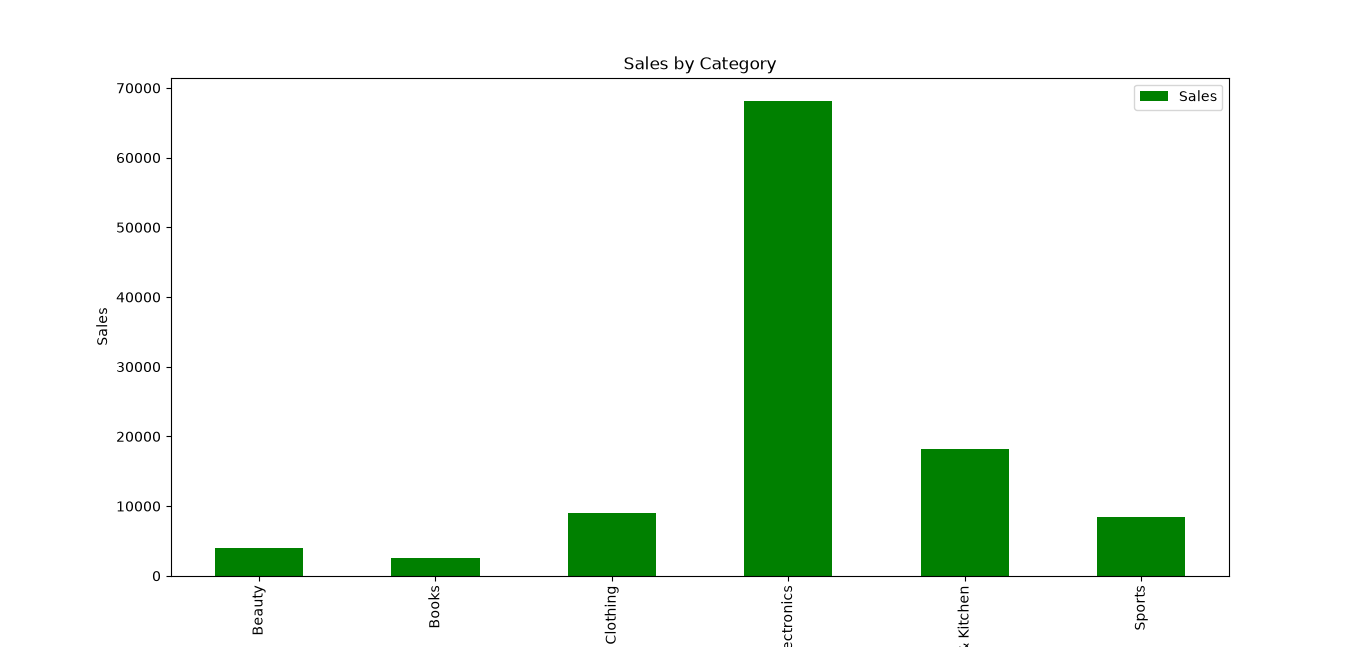

Insight: Highest sales category = Electronics


#3 Grouped bar chart — two dimensions together (e.g. sales by region and category)

In [ ]:
pivot = df.pivot_table(
    values="Sales",
    index="Region",
    columns="Category",
    aggfunc="sum"
)

pivot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Sales by Region and Category")

plt.xlabel("Region")

plt.ylabel("Sales")

plt.legend(title="Category")

plt.savefig(" sales by region and category.png")

plt.show()

print("Insight: Compare category sales across each region.")


![sales by region and category01.png](<attachment:sales by region and category01.png>)
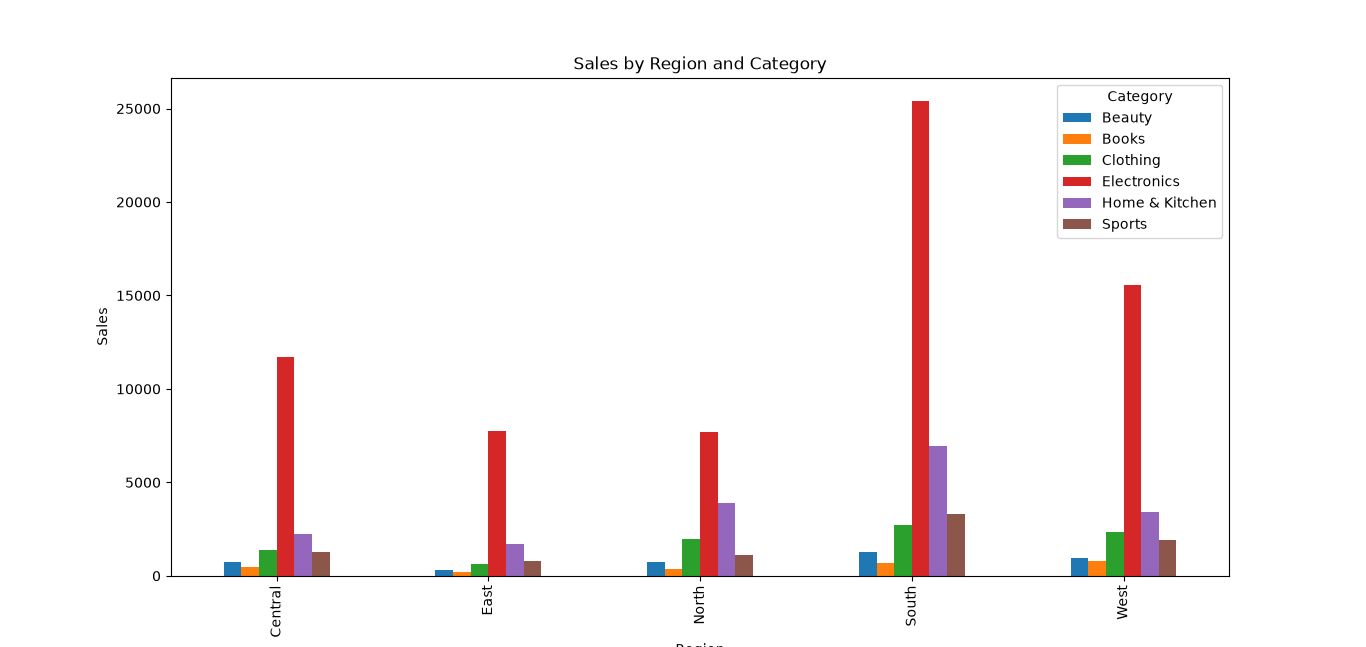

Insight: Compare category sales across each region.

#4 Histogram — distribution of a numeric column


In [ ]:
plt.figure(figsize=(8,6))

plt.hist(
    df["Sales"],
    bins=20,
    color="orange",
    edgecolor="black",
    label="Sales"
)

plt.title("Distribution of Sales")

plt.xlabel("Sales")

plt.ylabel("Frequency")

plt.legend()

plt.savefig("histogram.png")

plt.show()

print("Insight: Maximum sales =", df["Sales"].max())



![Distribution of sales01.png](<attachment:Distribution of sales01.png>)
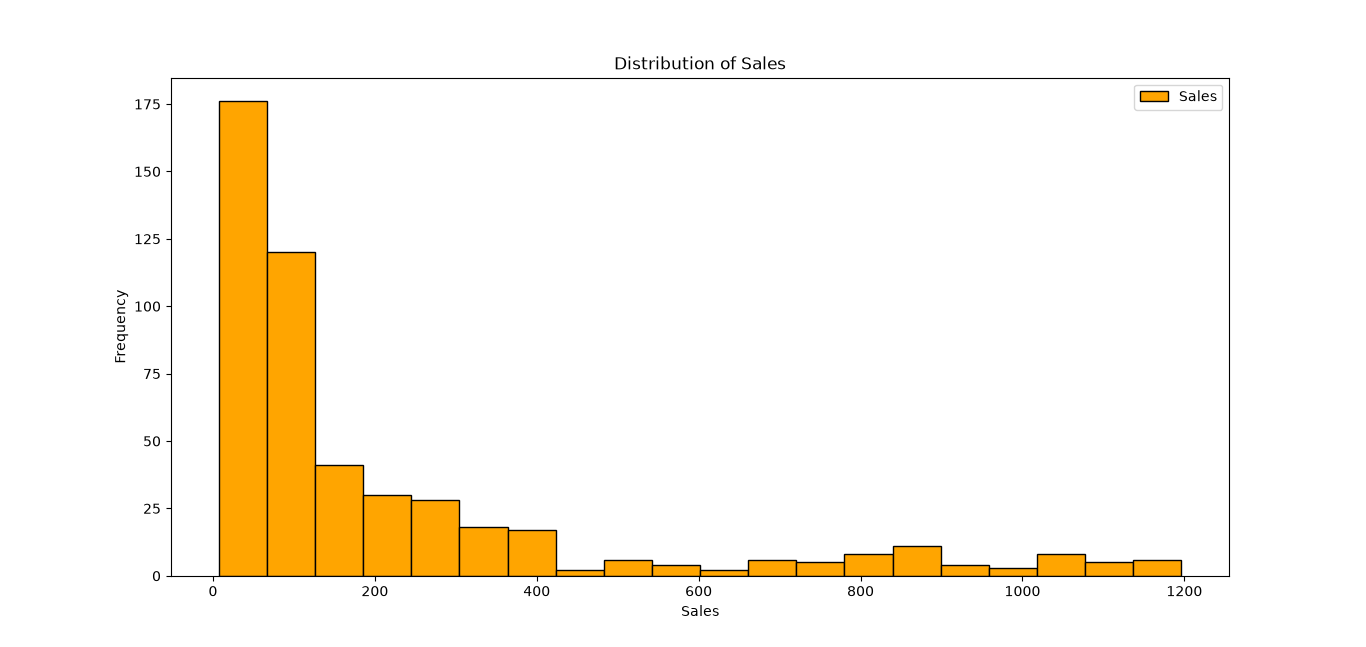

Insight: Maximum sales = 1196.17

#5 Scatter plot — relationship between two numeric columns


In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Sales"],
    df["Profit"],
    color="red",
    alpha=0.6,
    label="Orders"
)

plt.title("Sales vs Profit")

plt.xlabel("Sales")

plt.ylabel("Profit")

plt.legend()

plt.savefig("scatter_plot.png")

plt.show()

print("Insight: Highest profit =", df["Profit"].max())


![sales vs profit01.png](<attachment:sales vs profit01.png>)
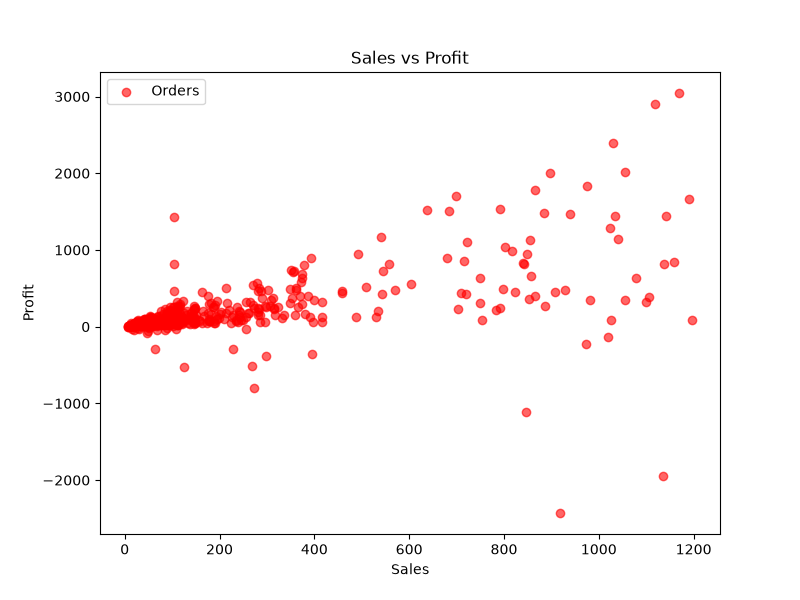

Insight: Highest profit = 3046.0

# 6 Box plot — spread and outliers in a numeric column


In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(
    y=df["Profit"],
    color="skyblue"
)

plt.title("Profit Box Plot")

plt.ylabel("Profit")

plt.savefig("box_plot.png")

plt.show()

print("Insight: Box plot shows outliers in Profit.")


![profit box plot01.png](<attachment:profit box plot01.png>)
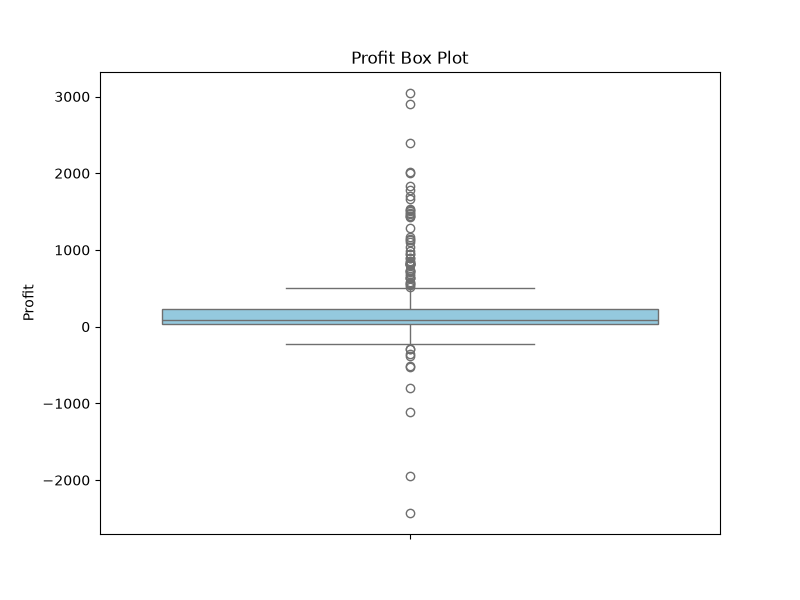

Insight: Box plot shows outliers in Profit.

#7 Correlation heatmap — all numeric columns


In [ ]:
numeric = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("heatmap.png")

plt.show()

print("Insight: Highest correlation =", numeric.corr().max().max())


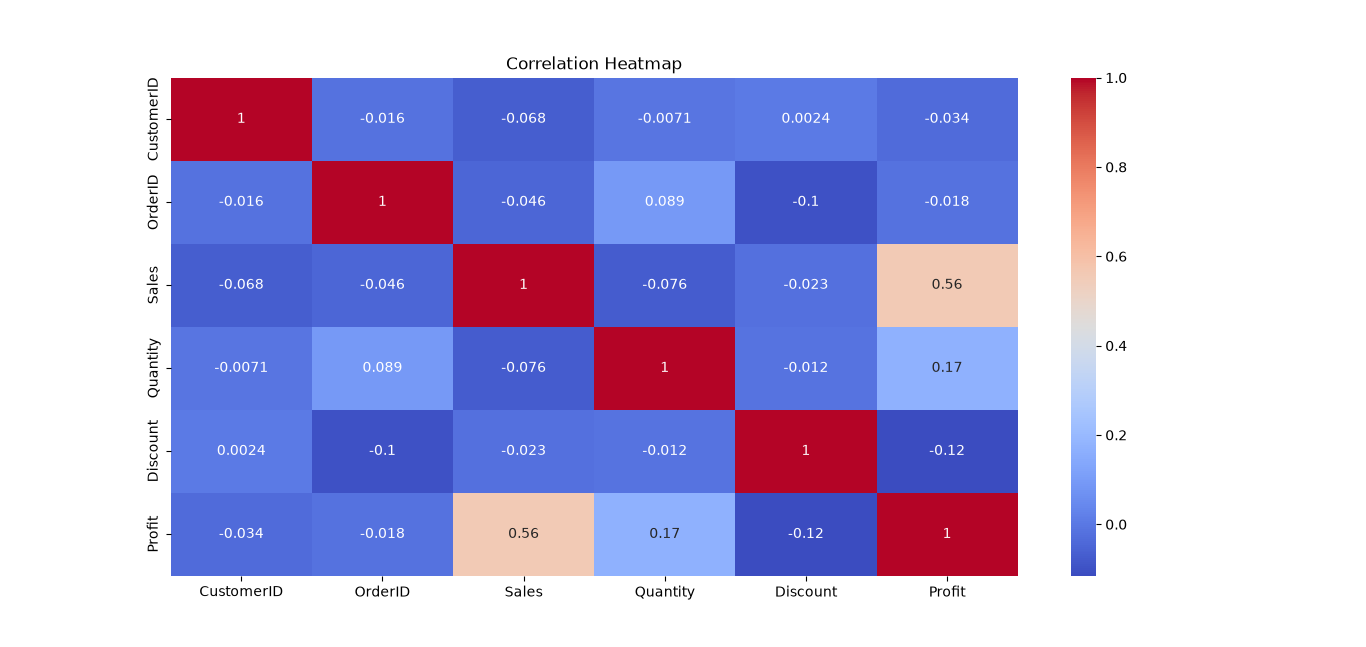

Insight: Highest correlation = 1.0

#8 One chart of your choice, justified in a comment
#Pie chart shows the percentage contribution of each category to total sales.


In [ ]:
category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales Share by Category")

plt.savefig("pie_chart.png")

plt.show()

print("Insight: Largest sales contribution comes from", category_sales.idxmax())


![pie chart01.png](<attachment:pie chart01.png>)
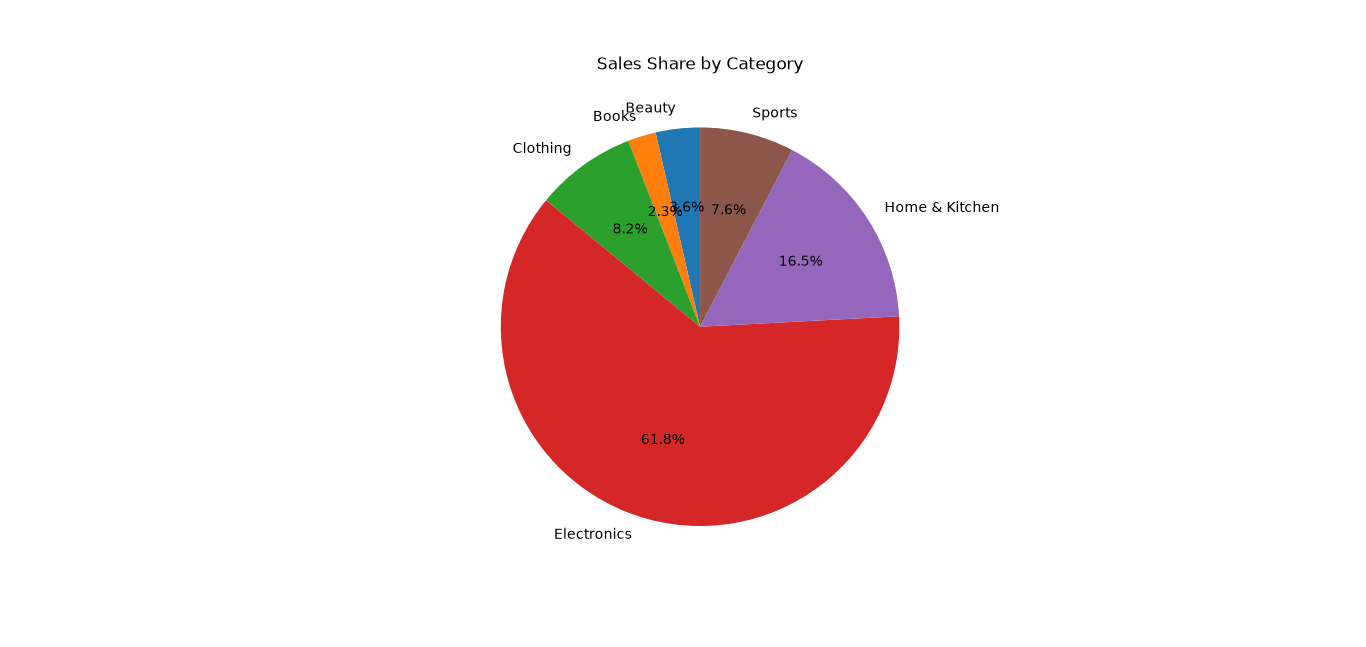

Insight: Largest sales contribution comes from Electronics